# Define all classes for attention analysis

In [1]:
import sys
sys.path.append("/home/motokawa/projects/MAEXP")
import torch
from core.agents.models.customs.da6_iqn_textStrat import DA6_IQN_TextStrat

class DA6_IQN_TextStratForAnalysis(DA6_IQN_TextStrat):
    def forward_attn(self, state, external_taus: torch.Tensor = None, attention_mode: str = "standard"):
        saliency_vector, attns = self.get_saliency_vector(
            state=state, output_attns=True, attention_mode=attention_mode
        )

        q_values = self.drl_head(
            state_embeddings=saliency_vector, external_taus=external_taus
        )

        return q_values, attns

    def get_saliency_vector(self, state, output_attns: bool = False, attention_mode: str = "standard"):
        local_x, relative_x, destination_x = self.state_encoder(state)

        out = self.relative_patch_embed(relative_x)
        relative_saliency_vector = self.relative_saliency_vector.expand(out.shape[0], -1, -1)
        out = torch.cat((relative_saliency_vector, out), dim=1)
        out = out + self.relative_pos_embed

        relative_attns = list()
        for blk in self.relative_blocks:
            out, attn = blk.forward_attn(out)
            attn.retain_grad()
            relative_attns.append(attn)

        out = self.cond_norm(out)
        relative_saliency_vector = out[:, 0]

        destination_saliency_vector = self.fc0(destination_x)

        saliency_vector = torch.cat([relative_saliency_vector, destination_saliency_vector], dim=1)
        saliency_vector = self.fc1(saliency_vector)

        out = self.local_patch_embed(local_x)
        saliency_vector = saliency_vector.unsqueeze(1)
        out = torch.cat((saliency_vector, out), dim=1)
        if attention_mode == "standard":
            out = out + self.local_pos_embed
        elif attention_mode == "positional":
            out = self.local_pos_embed

        local_attns = list()
        for blk in self.local_blocks:
            out, attn = blk.forward_attn(out)
            attn.retain_grad()
            local_attns.append(attn)

        out = self.norm(out)

        saliency_vector = out[:, 0]

        if output_attns:
            return saliency_vector, [local_attns, relative_attns]

        return saliency_vector

# Add config and init mdoel

In [2]:
import yaml
from omegaconf import DictConfig

with open("/home/motokawa/projects/MAEXP/configs/experiments/COMPSAC2026/new_da6_iqn_eval.yaml", "r") as file:
    config = DictConfig(yaml.safe_load(file))
config["model"] = {
  "name": "da6_iqn_textStrat",
  "attention": "normal",  # 'normal', 'hard'
  "af_lambd": 0.02,
  "embed_dim": 64,
  "patch_size": 1,
  "block_loop": 1,
  "num_heads": 4,
  "mlp_ratio": 4,
  "num_quantiles": 4,
  "num_quantiles_dash": 4,
  "num_cosines": 4,
  "hidden_layer_sizes": [128],
  "fc_afs": ['relu']
}
config["map"] = {
    "name": 'central_room_large_destination',
    "SIZE_X": 49,
    "SIZE_Y": 25,
    "root_dir": "/home/motokawa/projects/MAEXP/configs/experiments/COMPSAC2026/tensors/"
}

network = DA6_IQN_TextStratForAnalysis(config=config, input_shape=[10,49,25], output_size=4)

# Load pretrained weight

In [3]:
import wandb
import torch
from collections import OrderedDict

wandb.init()
agent_id = 0
weight_artifact = wandb.use_artifact("yoshi-0921/TextStrat-exp/1ohz7jq8.pth:v11", type="pretrained_weight")
weight_artifact_dir = weight_artifact.download()
state_dict = torch.load(weight_artifact_dir + f"/agent{agent_id}.pth", map_location="cpu")
new_state_dict = OrderedDict()
for key, value in state_dict.items():
    if key in network.state_dict().keys():
        new_state_dict[key] = value
network.load_state_dict(new_state_dict)
network.eval()
torch.manual_seed(921)
fixed_tau = torch.rand(1,config.model.num_quantiles).to("cpu")


Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: yoshi-0921 (use `wandb login --relogin` to force relogin)
wandb: wandb version 0.26.1 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade


# Main Analysis

  0%|          | 0/47 [00:00<?, ?it/s]

Generating mask: 100%|██████████| 47/47 [00:02<00:00, 17.71it/s]
[INFO] [2026-05-04 11:14:57,576] [destination_handler.py:72] 
 Using TensorDestinationHandler for destination areas
Generating mask: 100%|██████████| 47/47 [00:02<00:00, 18.24it/s]
[INFO] [2026-05-04 11:15:00,158] [destination_handler.py:72] 
 Using TensorDestinationHandler for destination areas


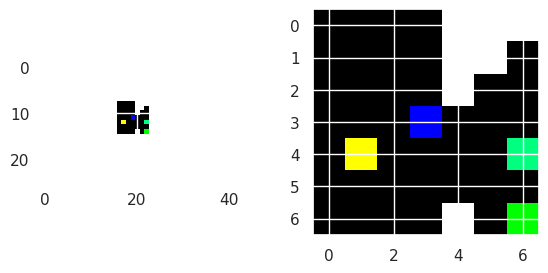

In [43]:
import numpy as np
import random
from core.maps.central_room_large_destination_map import CentralRoomLargeDestinationMap
from core.worlds.default_world import DefaultWorld
from core.environments.default_environment import DefaultEnvironment

class TestCentralRoomLargeDestinationMap(CentralRoomLargeDestinationMap):
    def reset_destination_area(self):
        destination_area = [np.zeros(shape=(self.SIZE_X, self.SIZE_Y), dtype=np.int8) for _ in range(4)]
        destination_area[0][: self.SIZE_X // 2, :] = 1  # left half
        destination_area[1][self.SIZE_X // 2:, :] = 1  # right half
        destination_area[2][:, : self.SIZE_Y // 2] = 1  # top half
        destination_area[3][:, self.SIZE_Y // 2:] = 1  # bottom half

        for agent_id in range(self.num_agents):
            area_id = random.choice(range(len(destination_area)))
            object_type = random.choice(range(self.type_objects))
            self.destination_area_matrix[agent_id] = destination_area[area_id]
            self.destination_area_vector[agent_id] = random.choice(self.tensors[area_id])
            # self.destination_area_vector[agent_id] = random.choice(self.tensors[object_type][area_id])
            # self.specified_object_types[agent_id] = str(object_type)

        self.destination_area_matrix[0] = destination_area[0]
        self.destination_area_vector[0] = self.tensors[0][1]

class TestEnvironment(DefaultEnvironment):
    def __init__(self, config, world):
        super().__init__(config=config, world=world)
        agent_xys = [
            # [14,8],[-6,-10],[-7,-7],[-8,-9],[-7,-9],[-6,-9],[-5,-9],[-4,-9]
            [-5, 1], [0, 2], [2, 2], [-2, 0], [2, 0], [-2, -2], [0, -2], [2, -2]
            ]
        for agent_id, agent_xy in enumerate(agent_xys):
            self.init_xys[agent_id] = np.asarray(agent_xy, dtype=np.int8)

    # def generate_objects(self, num_objects: int = None, object_type: int = None):
    #     object_xys = [
    #         [16, 8], [12, 5]
    #         # [6, 4], [7, 4], [8,4]
    #         # [-1, -3], [0, -3], [1,-3]
    #         # [-8, -4], [-7, -4], [-6,-4]
    #         ]
    #     for object_xy in object_xys:
    #         x, y = self.world.map.coord2ind(object_xy)
    #         self.world.map.objects_matrix[0, x, y] = 1
    #         self.heatmap_objects[0, x, y] += 1
    #         self.objects_generated += 1

world_map = TestCentralRoomLargeDestinationMap(config=config, size_x=49, size_y=25)
world = DefaultWorld(config=config, world_map=world_map)
env = TestEnvironment(config=config, world=world)
env.reset()

import matplotlib.pyplot as plt
state=env.observation_ind(env.agents,env.agents[agent_id],agent_id)
images=env.observation_handler.render(state)
plt.subplot(1, 2, 1)
plt.imshow(images["relative"].permute(1, 2, 0))
plt.subplot(1, 2, 2)
plt.imshow(images["local"].permute(1, 2, 0))

for state_key, state_value in state.items():
    if isinstance(state_value, torch.Tensor):
        state[state_key] = state_value.unsqueeze(0).float().to("cpu")

In [44]:
env.world.map.destination_area_matrix[0].T

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]], dtype=int8)

Action: RIGHT, Q-value: 2.495210647583008
Action: UP, Q-value: 2.576218366622925
Action: LEFT, Q-value: 2.8623251914978027
Action: DOWN, Q-value: 2.6271414756774902
Final action selected: LEFT, Q-value: 2.862


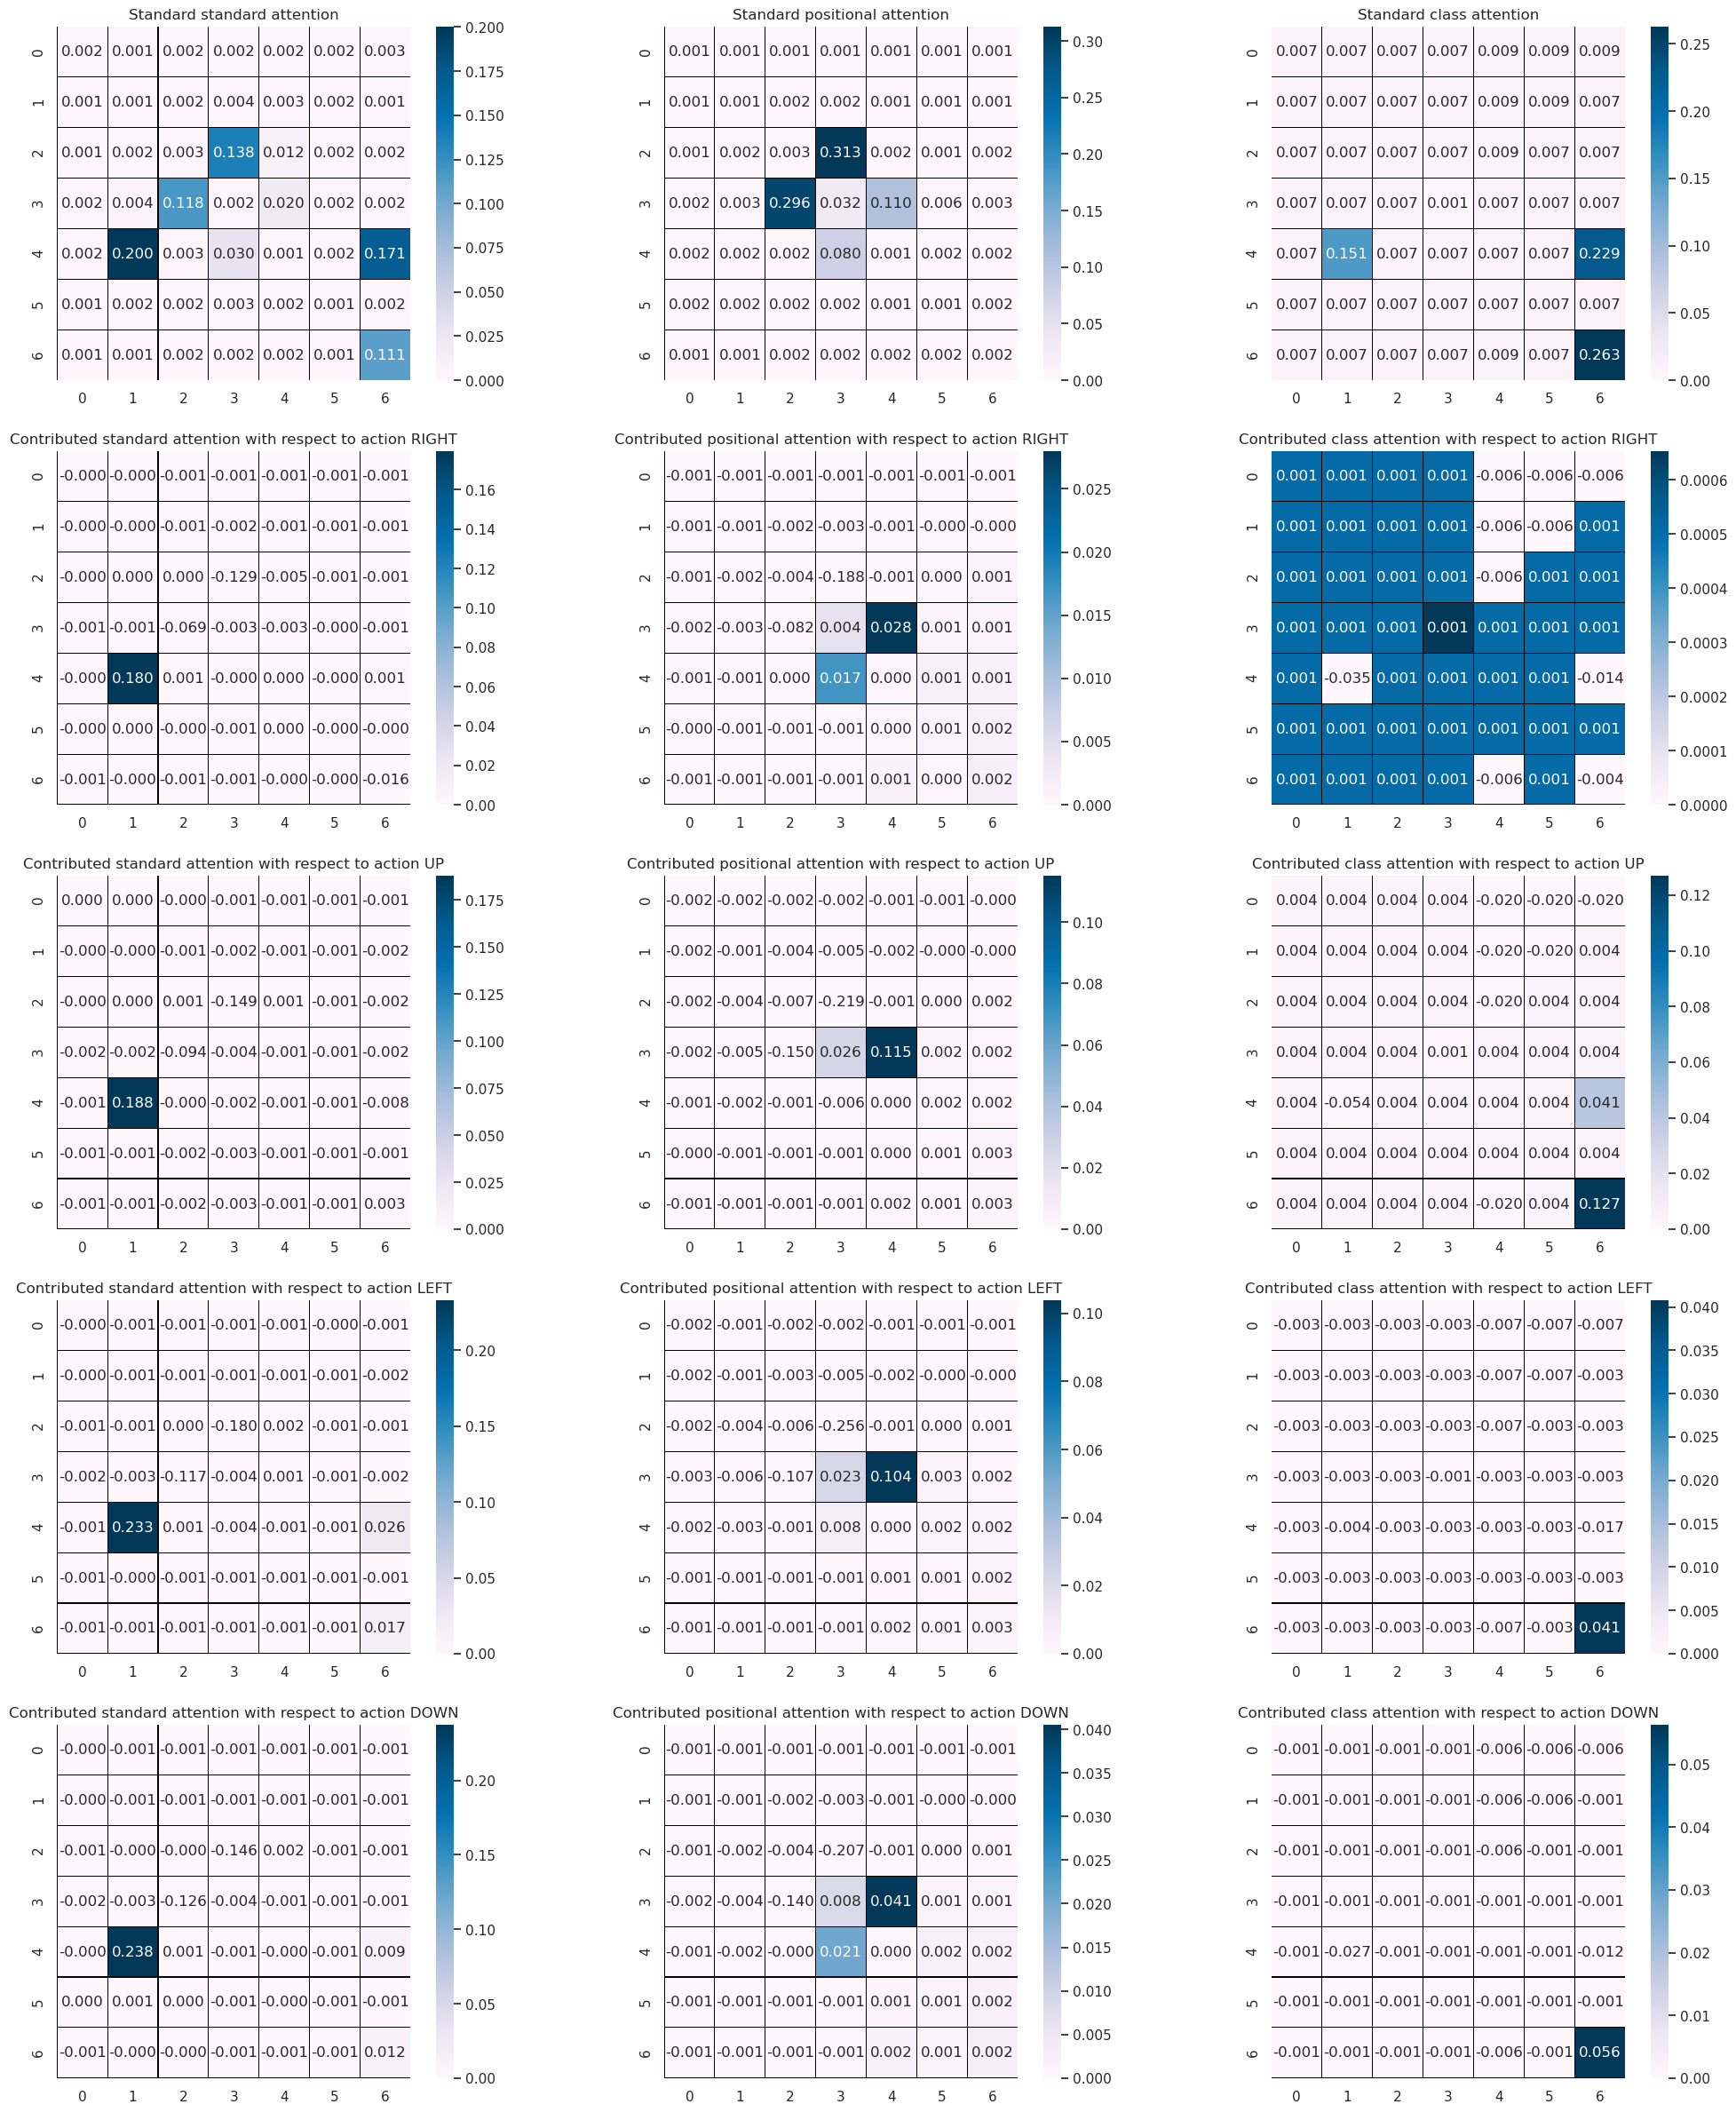

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
sns.set()

actions={0:"RIGHT", 1:"UP", 2:"LEFT", 3:"DOWN"}
fig = plt.figure(figsize=(25, 30))

for attention_mode_i, attention_mode in enumerate(["standard", "positional","class"]):
    network.zero_grad()
    q_values, attns = network.forward_attn(state,external_taus=fixed_tau,attention_mode=attention_mode)
    attention_map = torch.stack(attns[0])
    attention_map = attention_map.mean(dim=0)[0, :, 0, 1:].view(-1,7,7).cpu()
    plt.subplot(5, 3, attention_mode_i+1)
    sns.heatmap(
        torch.t(attention_map.mean(dim=0)).detach().numpy(),
        cmap='PuBu',
        linecolor='black',
        linewidths=.1,
        vmin=0,
        square=True,
        annot=True,
        fmt=".3f",
        # vmax=0.25,
        annot_kws={"fontsize": 12},
    )
    plt.title(f"Standard {attention_mode} attention")

for action_i in range(4):
    for attention_mode_i, attention_mode in enumerate(["standard", "positional","class"]):
        network.zero_grad()
        q_values, attns = network.forward_attn(state,external_taus=fixed_tau,attention_mode=attention_mode)
        q_values[0,action_i].backward(retain_graph=True)
        if attention_mode == "standard":
            print(f"Action: {actions[action_i]}, Q-value: {q_values[0, action_i].item()}")
            if action_i == 3:
                print(f"Final action selected: {actions[q_values.argmax(dim=1).item()]}, Q-value: {q_values[0, q_values.argmax(dim=1).item()].item():.3f}")

        # attns[0] for local, attns[1] for relative
        attention_map = torch.stack(attns[0])
        attention_grads= torch.stack([a.grad for a in attns[0]])
        attention_map_grads = (attention_map*attention_grads).mean(dim=0)[0, :, 0, 1:].view(-1,7,7).cpu()
        attention_map = attention_map.mean(dim=0)[0, :, 0, 1:].view(-1,7,7).cpu()

        plt.subplot(5, 3, (action_i+1)*3+attention_mode_i+1)
        sns.heatmap(
            torch.t(attention_map_grads.mean(dim=0)).detach().numpy(),
            cmap='PuBu',
            linecolor='black',
            linewidths=.1,
            vmin=0,
            square=True,
            annot=True,
            fmt=".3f",
            # vmax=0.25,
            annot_kws={"fontsize": 12},
        )
        plt.title(f"Contributed {attention_mode} attention with respect to action {actions[action_i]}")

# Utils

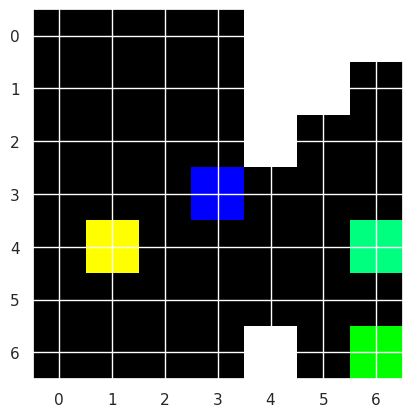

In [46]:
import matplotlib.pyplot as plt
state=env.observation_ind(env.agents,env.agents[agent_id],agent_id)
images=env.observation_handler.render(state)
plt.imshow(images["local"].permute(1, 2, 0))

for state_key, state_value in state.items():
    if isinstance(state_value, torch.Tensor):
        state[state_key] = state_value.unsqueeze(0).float().to("cpu")

network.zero_grad()
q_values, attns = network.forward_attn(state,external_taus=fixed_tau,attention_mode="positional")
q_values[0,0].backward(retain_graph=True)

<AxesSubplot:>

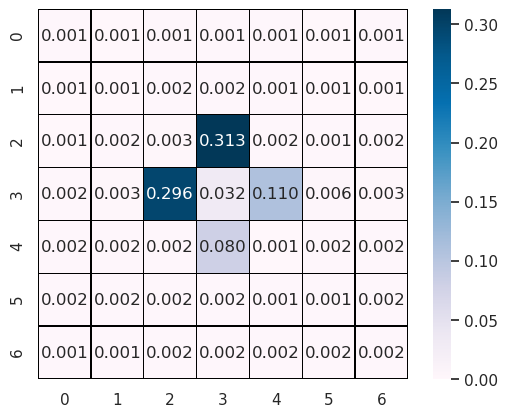

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
sns.set()

# attns[0] for local, attns[1] for relative
attention_map = torch.stack(attns[0])
attention_map = attention_map.mean(dim=0)[0, :, 0, 1:].view(-1,7,7).cpu()

fig = plt.figure()
sns.heatmap(
    torch.t(attention_map.mean(dim=0)).detach().numpy(),
    cmap='PuBu',
    linecolor='black',
    linewidths=.1,
    vmin=0,
    square=True,
    annot=True,
    fmt=".3f",
    # vmax=0.25,
    annot_kws={"fontsize": 12},
)

<AxesSubplot:>

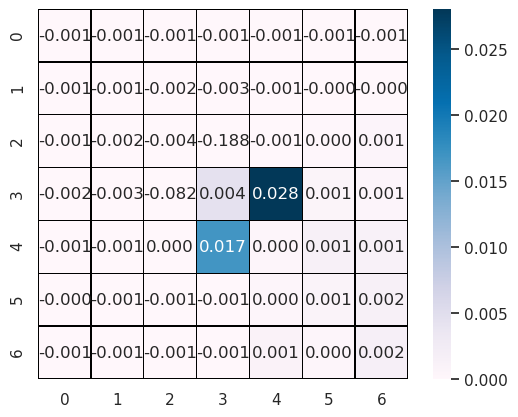

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
sns.set()

# attns[0] for local, attns[1] for relative
attention_map = torch.stack(attns[0])
attention_grads= torch.stack([a.grad for a in attns[0]])
attention_map = (attention_map*attention_grads).mean(dim=0)[0, :, 0, 1:].view(-1,7,7).cpu()

fig = plt.figure()
sns.heatmap(
    torch.t(attention_map.mean(dim=0)).detach().numpy(),
    cmap='PuBu',
    linecolor='black',
    linewidths=.1,
    vmin=0,
    square=True,
    annot=True,
    fmt=".3f",
    # vmax=0.25,
    annot_kws={"fontsize": 12},
)


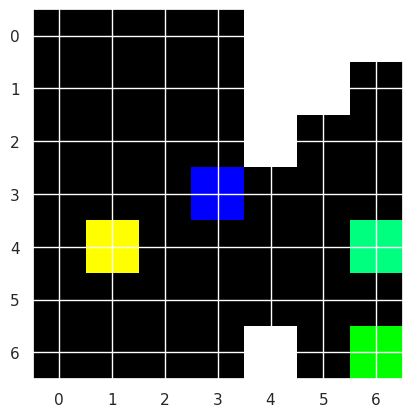

In [49]:
plt.imshow(images["local"].permute(1, 2, 0))